In [2]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk

from rsp.plotting import Rsp_Kit  # Your class for plotting

import sys

if '__file__' in globals():
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
else:
    SCRIPT_DIR = os.getcwd()  # Fallback for notebooks and interactive environments

def analyze_and_plot_breathing(h5_file, output_dir=None, target_rate=100):
    
    if output_dir is None:
            output_dir = os.path.join(SCRIPT_DIR, "plots")
    
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
    except Exception as e:
        return {"file": os.path.basename(h5_file), "error": str(e)}

    try:
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except KeyError:
        return {"file": os.path.basename(h5_file), "error": "Missing 'duration_sec' metadata"}

    # Step 1: Pre-downsampling low-pass filter
    cutoff_hz = fs / 2
    nyquist = fs / 2
    norm_cutoff = cutoff_hz / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Step 2: Downsample
    downsample_factor = int(fs // target_rate)
    downsampled_resp = resample_poly(filtered_resp, up=1, down=downsample_factor)
    duration_downsampled = len(downsampled_resp) / target_rate

    # Step 3: Apply neurokit2 Butterworth bandpass filter after downsampling
    rsp_cleaned = nk.signal_filter(
        downsampled_resp,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Step 4: Peak detection
    peaks, _ = find_peaks(rsp_cleaned, distance=target_rate // 20)
    breathing_rate_hz = len(peaks) / duration_downsampled

    # Step 5: Plot with Rsp_Kit
    try:
        os.makedirs(output_dir, exist_ok=True)
        rsp_obj = Rsp_Kit.Rsp_Kit(rsp_cleaned, fs=target_rate, n_samples=len(rsp_cleaned))
        fig = rsp_obj.plot(start_time=5, duration=10, show_peaks=True, title=os.path.basename(h5_file))
        plot_path = os.path.join(output_dir, os.path.basename(h5_file).replace(".h5", "_10s_plot.png"))
        plt.savefig(plot_path)
        plt.close()
    except Exception as plot_err:
        return {"file": os.path.basename(h5_file), "error": f"Plotting failed: {plot_err}"}

    return {
        "file": os.path.basename(h5_file),
        "original_fs": round(fs, 2),
        "duration_sec": round(duration_sec, 2),
        "downsampled_len": len(downsampled_resp),
        "duration_downsampled": round(duration_downsampled, 2),
        "peak_count": len(peaks),
        "breathing_rate_hz": round(breathing_rate_hz, 2),
        "plot_path": plot_path
    }

def batch_analyze_directory(directory_path):
    results = []
    output_dir = os.path.join(SCRIPT_DIR, "plots")  # Ensures plots folder is in same directory as script
    for file in os.listdir(directory_path):
        if file.endswith(".h5"):
            full_path = os.path.join(directory_path, file)
            result = analyze_and_plot_breathing(full_path, output_dir=output_dir)
            results.append(result)
    return pd.DataFrame(results)

# 👉 SET YOUR DIRECTORY PATH HERE
if __name__ == "__main__":
    directory = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_twice_analog_h5_outputs"
    df_results = batch_analyze_directory(directory)
    print(df_results.to_string(index=False))


ValueError: Digital filter critical frequencies must be 0 < Wn < 1

### Cagemate day 1

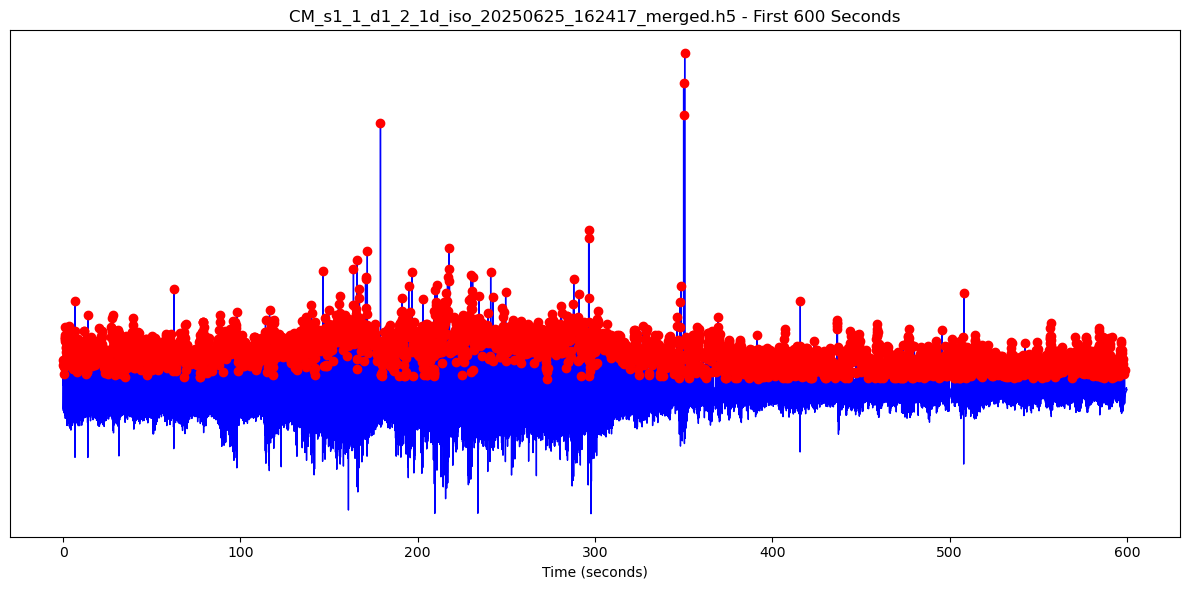

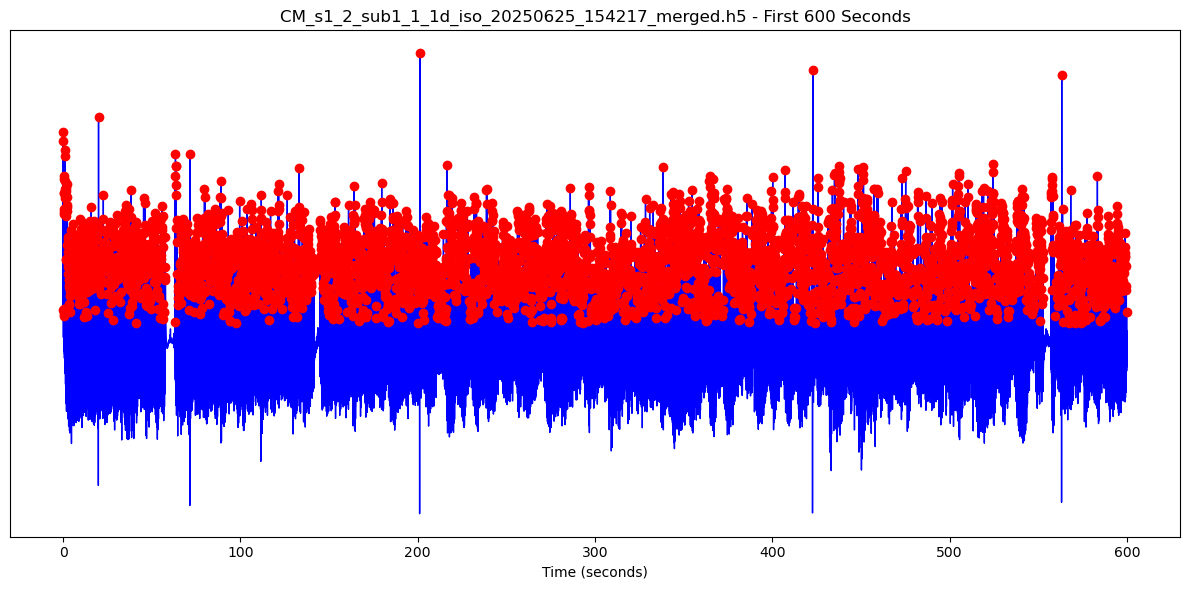

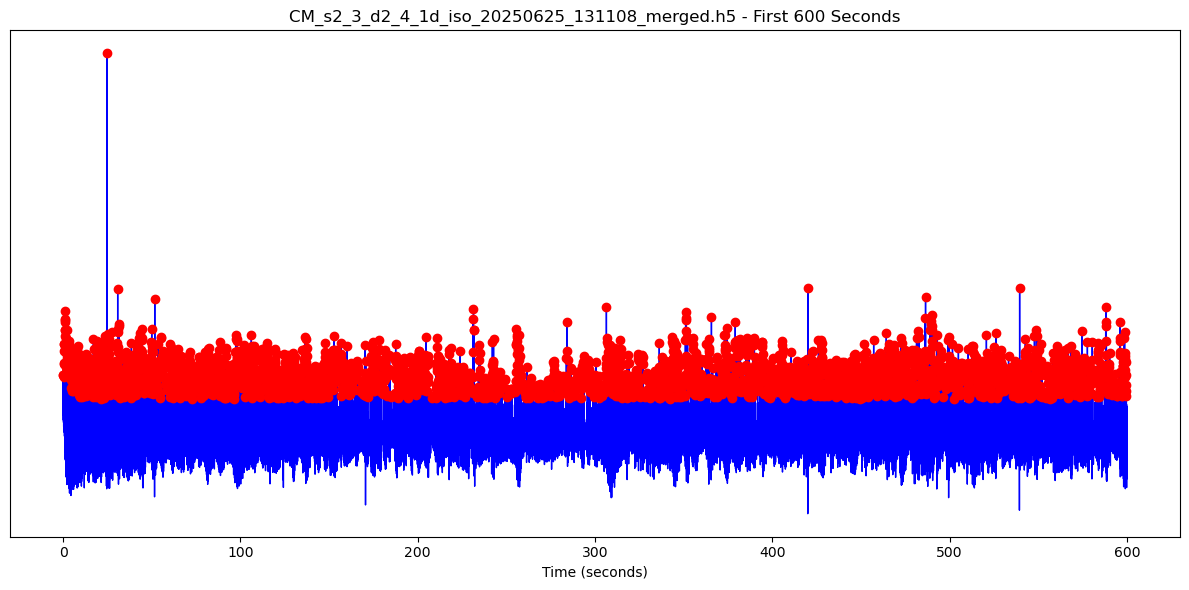

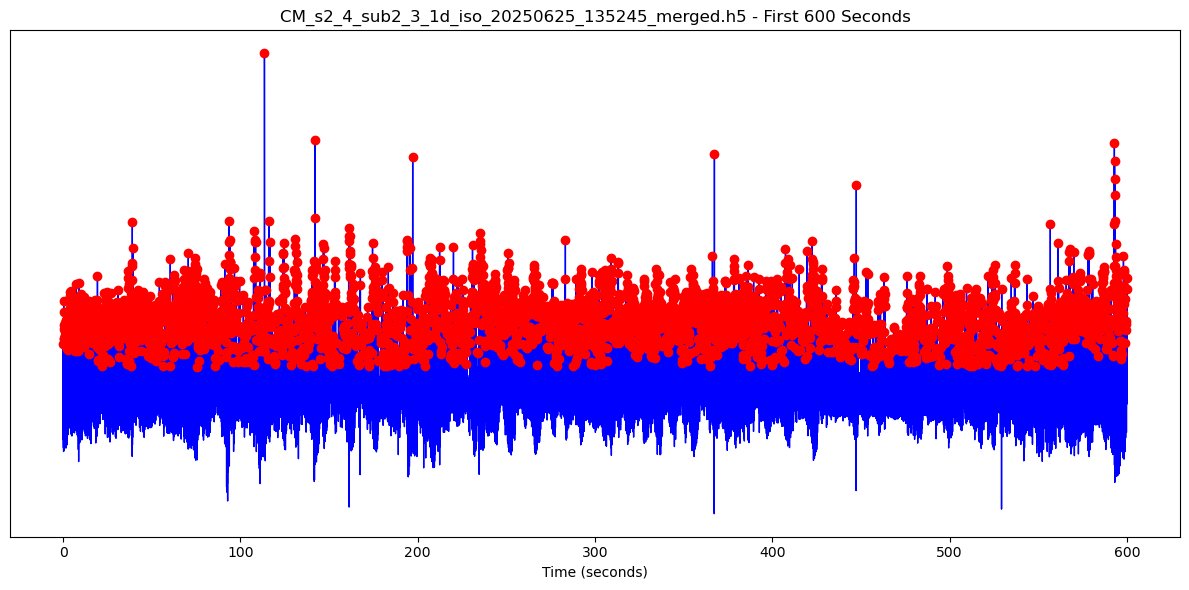

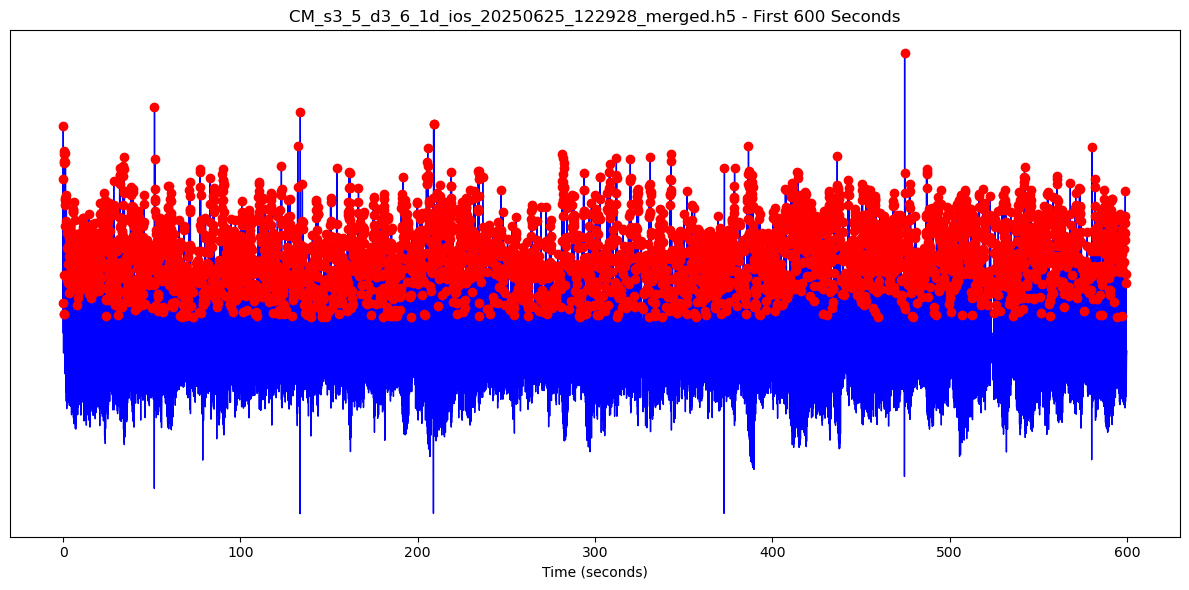

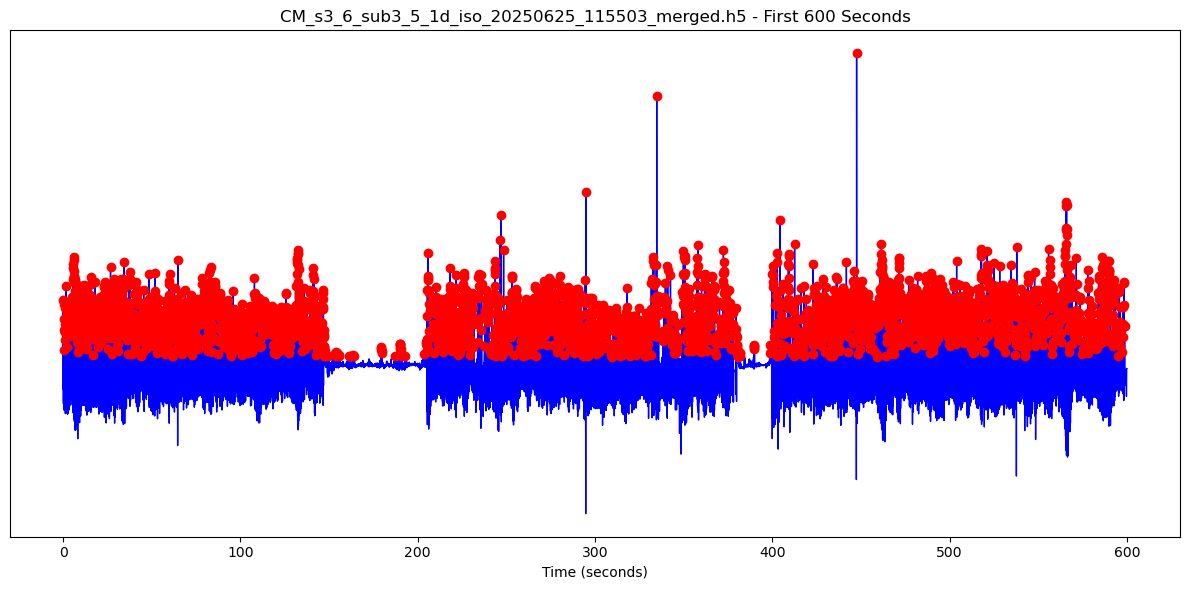

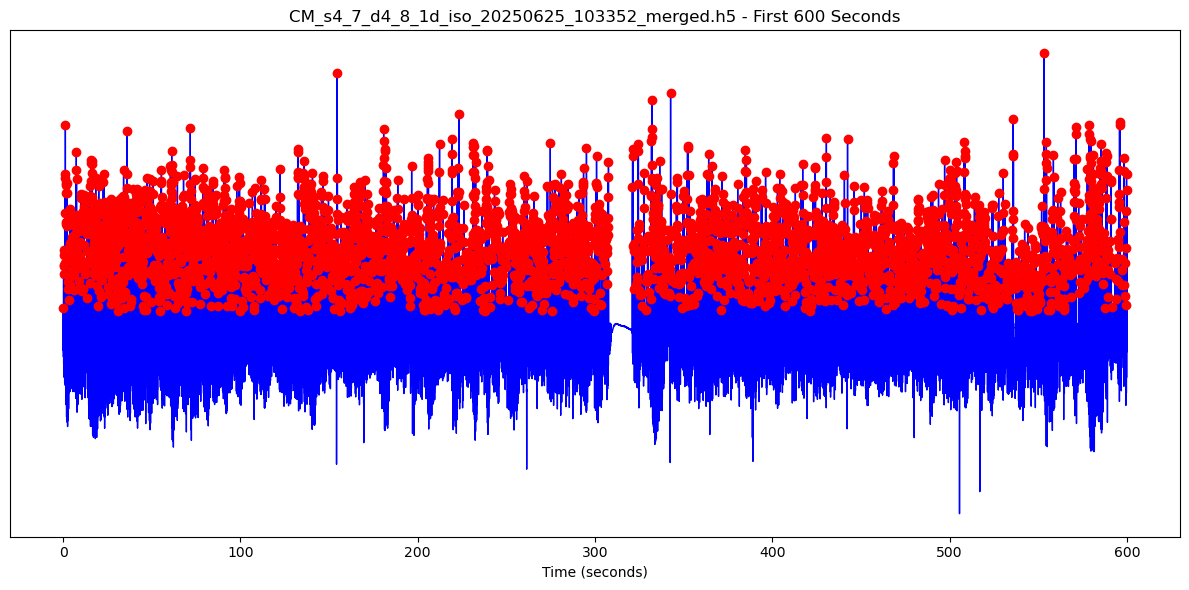

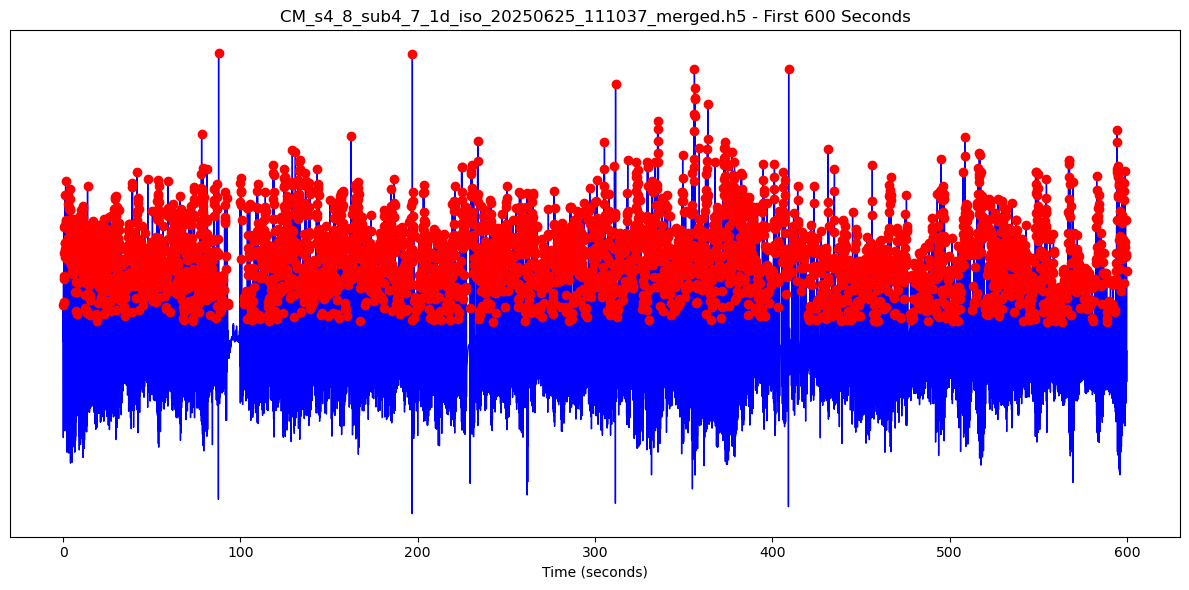

                                           file  original_fs  duration_sec  downsampled_len  duration_downsampled  peak_count  breathing_rate_hz                                                                                                                                                        plot_path
  CM_s1_1_d1_2_1d_iso_20250625_162417_merged.h5        20000        602.29            60230                602.30        4660               7.74   C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\cagemate_day_1_h5_outputs\plots\CM_s1_1_d1_2_1d_iso_20250625_162417_merged_10s_plot.png
CM_s1_2_sub1_1_1d_iso_20250625_154217_merged.h5        20000        619.24            61925                619.25        5574               9.00 C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\cagemate_day_1_h5_outputs\plots\CM_s1_2_sub1_1_1d_iso_20250625_154217_merged_10s_plot.png
  CM_s2_3_d2_4_1d_iso_20250625_131108_merged.h5        20000        601.99        

In [ ]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk

from rsp.plotting import Rsp_Kit  # Your class for plotting

def analyze_and_plot_breathing(h5_file, output_dir="plots", target_rate=100):
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            resp_meta = dict(f['resp_metadata'].attrs)
            # ekg_meta = dict(f['ekg_metadata'].attrs)
    except Exception as e:
        return {"file": os.path.basename(h5_file), "error": str(e)}

    try:
        duration_sec = resp_meta['duration_sec']
        # fs = len(resp) / duration_sec
        fs = 20000
    except KeyError:
        return {"file": os.path.basename(h5_file), "error": "Missing 'duration_sec' metadata"}

    # Step 1: Pre-downsampling low-pass filter
    cutoff_hz = 0.45 * target_rate     # desired cutoff, slightly below new Nyquist
    nyquist = fs / 2                   # current Nyquist of the data
    norm_cutoff = cutoff_hz / nyquist  # normalized cutoff for filter design
    b, a = butter(4, norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)


    # Step 2: Downsample
    downsample_factor = int(fs // target_rate)
    downsampled_resp = resample_poly(filtered_resp, up=1, down=downsample_factor)
    duration_downsampled = len(downsampled_resp) / target_rate

    # Step 3: Apply neurokit2 Butterworth bandpass filter after downsampling
    rsp_cleaned = nk.signal_filter(
        downsampled_resp,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Step 4: Peak detection
    peaks, _ = find_peaks(rsp_cleaned, distance=target_rate // 20)
    breathing_rate_hz = len(peaks) / duration_downsampled

    # Step 5: Plot with Rsp_Kit
    try:
        os.makedirs(output_dir, exist_ok=True)
        rsp_obj = Rsp_Kit.Rsp_Kit(rsp_cleaned, fs=target_rate, n_samples=len(rsp_cleaned))
        fig = rsp_obj.plot(duration=600, show_peaks=True, title=os.path.basename(h5_file))
        plot_path = os.path.join(output_dir, os.path.basename(h5_file).replace(".h5", "_10s_plot.png"))
        plt.savefig(plot_path)
        plt.close()
    except Exception as plot_err:
        return {"file": os.path.basename(h5_file), "error": f"Plotting failed: {plot_err}"}

    return {
        "file": os.path.basename(h5_file),
        "original_fs": round(fs, 2),
        "duration_sec": round(duration_sec, 2),
        "downsampled_len": len(downsampled_resp),
        "duration_downsampled": round(duration_downsampled, 2),
        "peak_count": len(peaks),
        "breathing_rate_hz": round(breathing_rate_hz, 2),
        "plot_path": plot_path
    }

def batch_analyze_directory(directory_path):
    results = []
    plot_output_dir = os.path.join(directory_path, "plots")
    for file in os.listdir(directory_path):
        if file.endswith(".h5"):
            full_path = os.path.join(directory_path, file)
            result = analyze_and_plot_breathing(full_path, output_dir=plot_output_dir)
            results.append(result)
    return pd.DataFrame(results)

# 👉 SET YOUR DIRECTORY PATH HERE
if __name__ == "__main__":
    # directory = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_twice_analog_h5_outputs"
    directory = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\cagemate_day_1_h5_outputs"
    
    df_results = batch_analyze_directory(directory)
    # save results to CSV
    results_csv_path = os.path.join(directory, "breathing_analysis_results.csv")
    df_results.to_csv(results_csv_path, index=False)
    
    print(df_results.to_string(index=False))


### 10 day cagemate

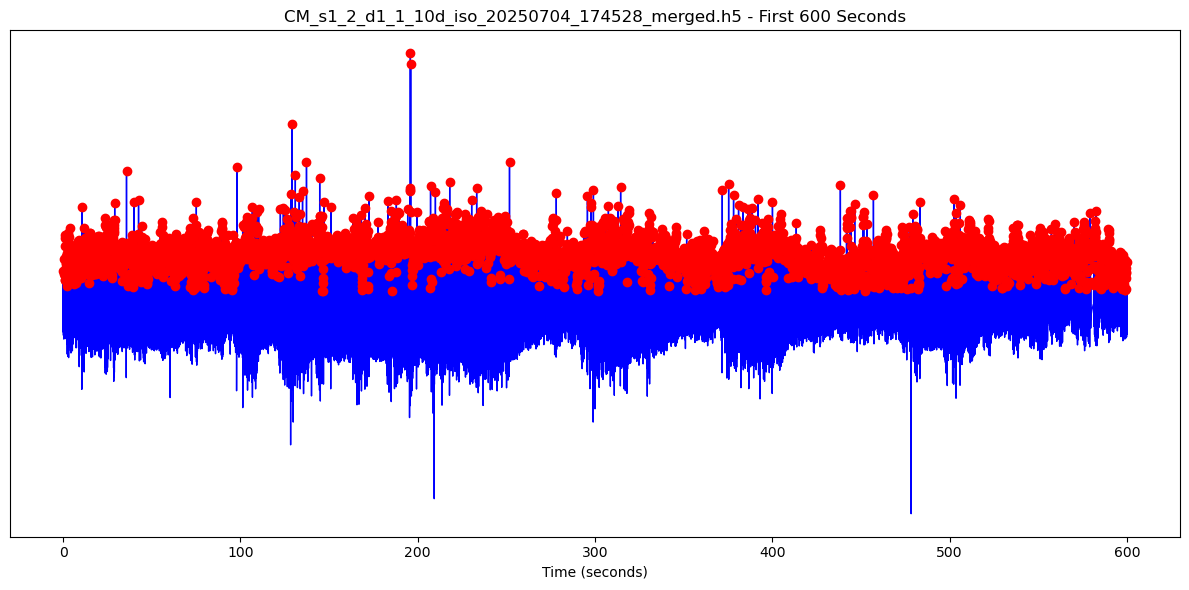

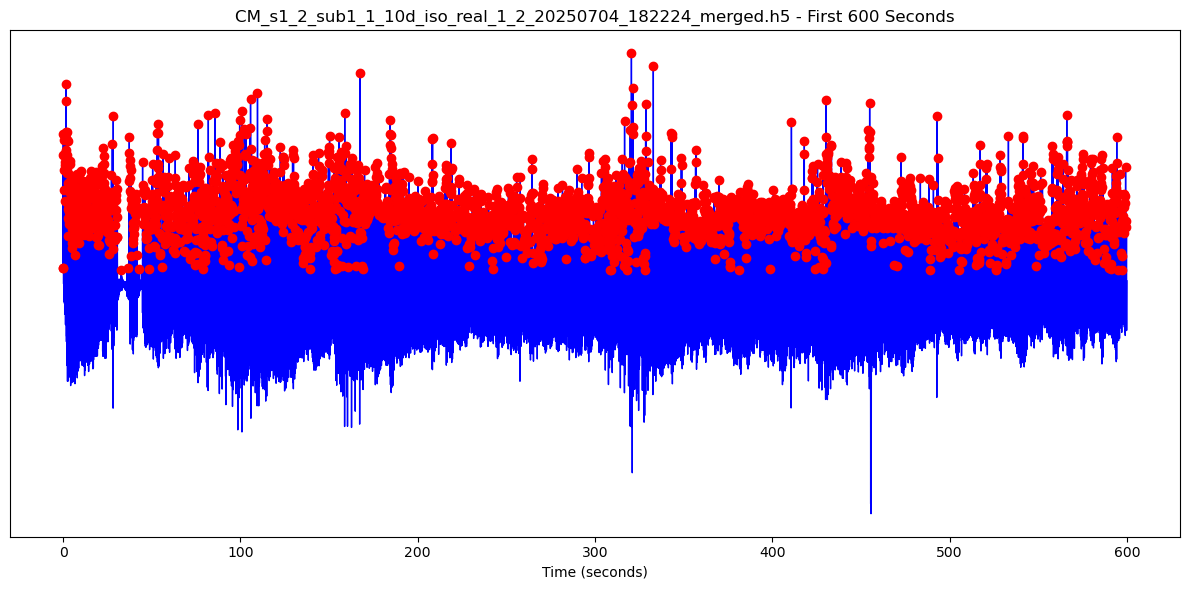

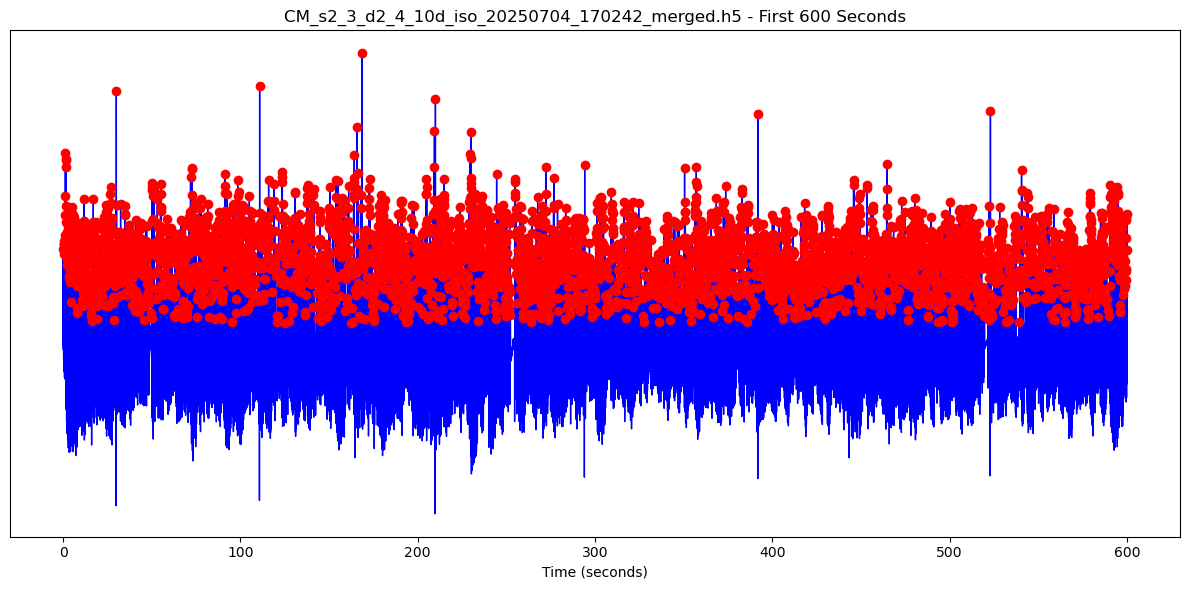

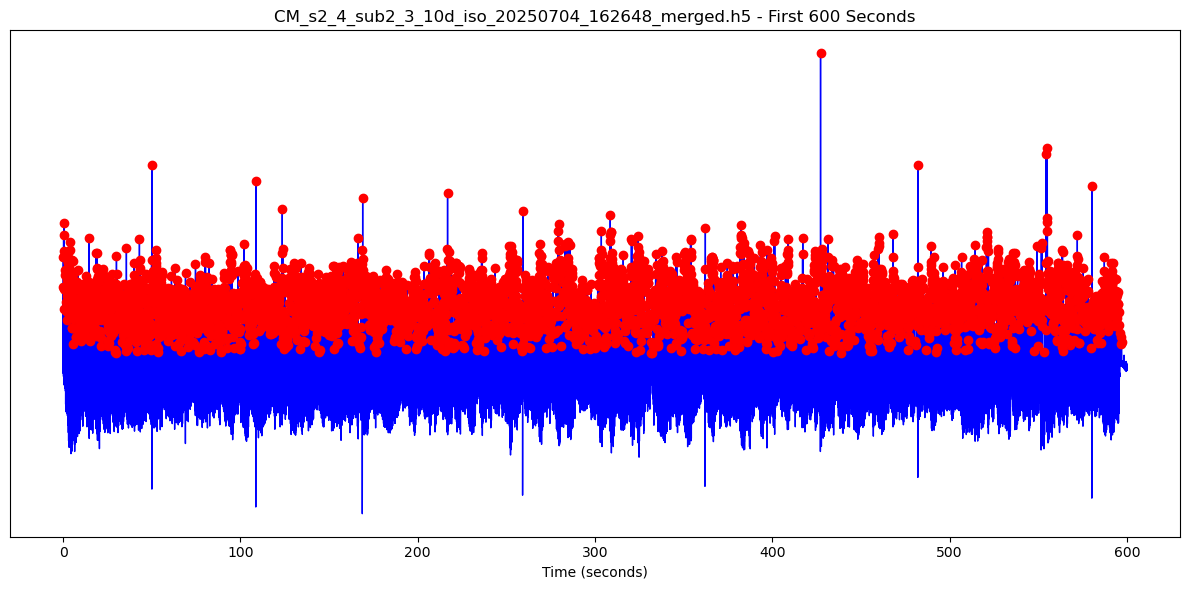

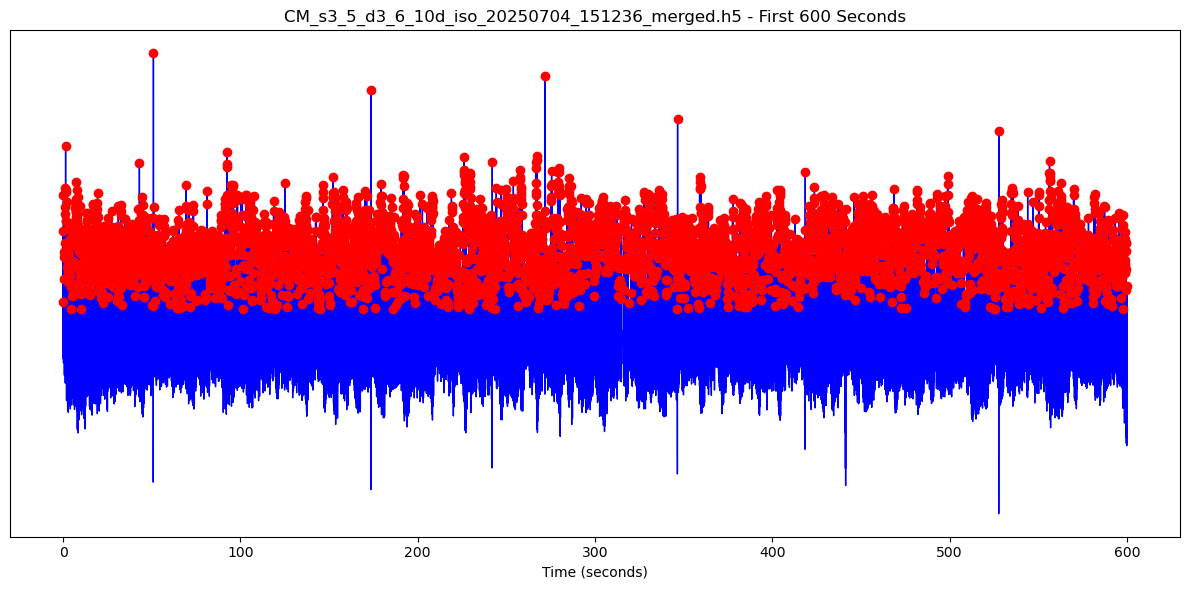

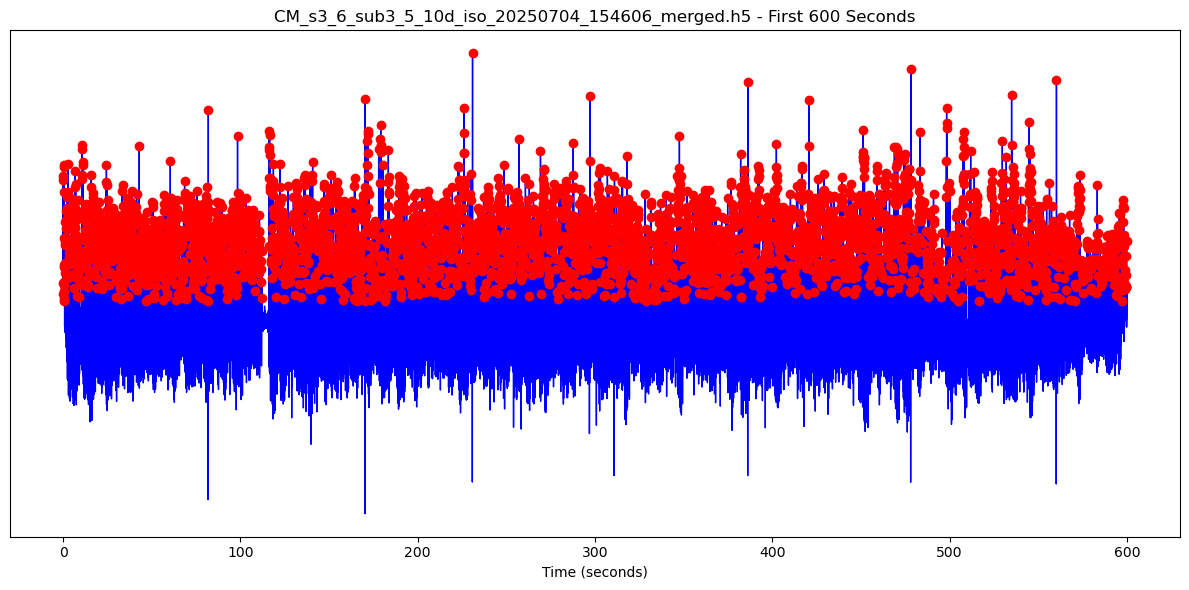

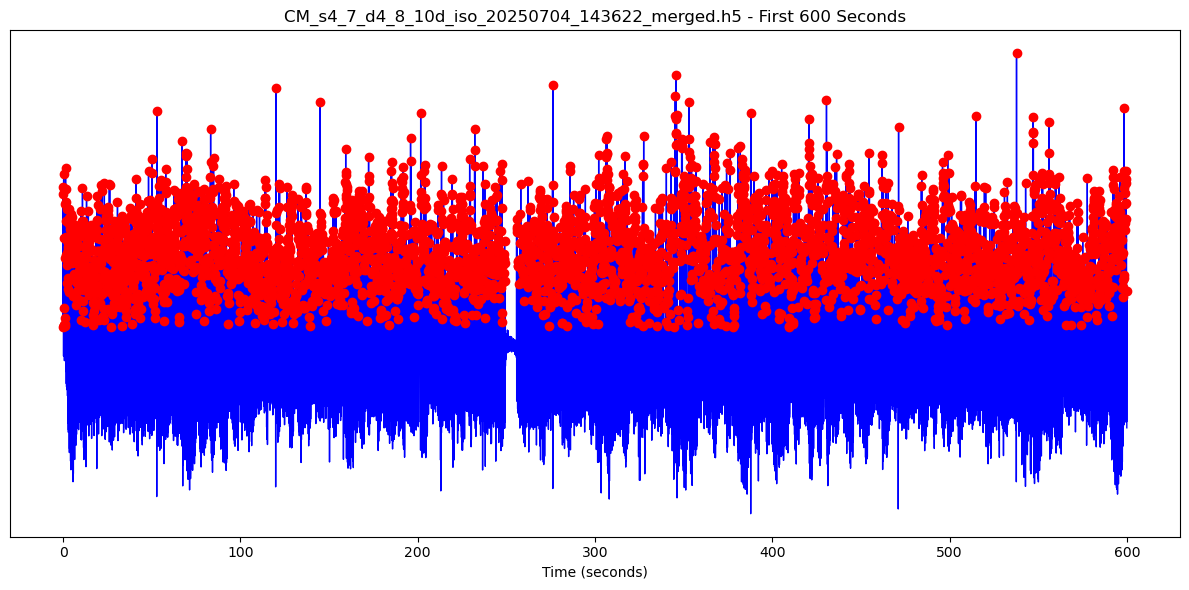

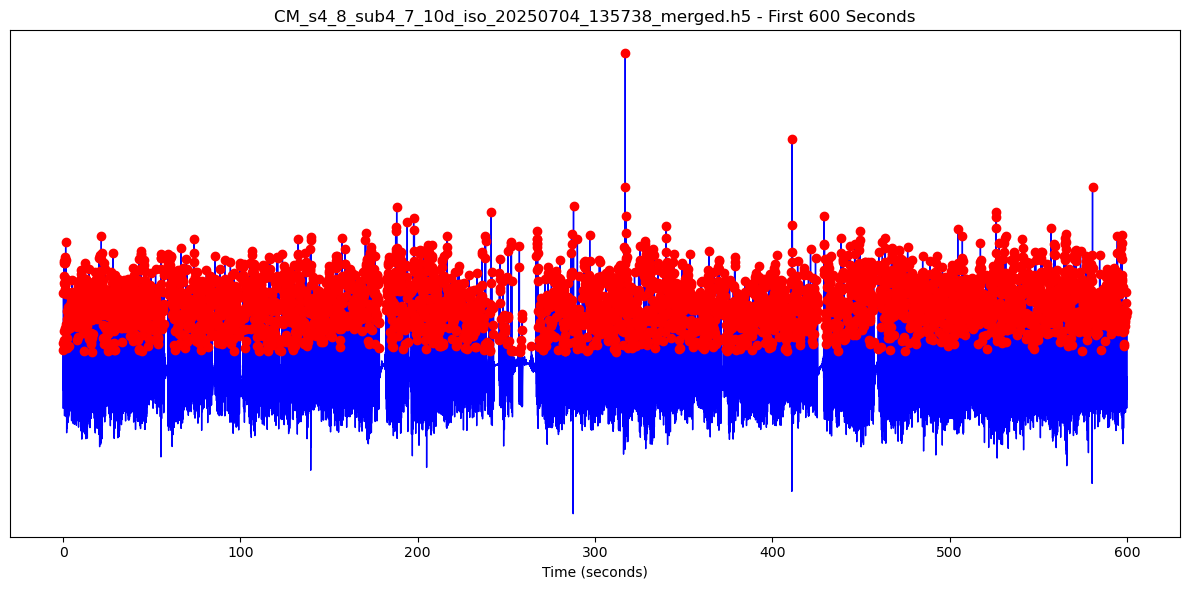

                                                     file  original_fs  duration_sec  downsampled_len  duration_downsampled  peak_count  breathing_rate_hz                                                                                                                                                                   plot_path
           CM_s1_2_d1_1_10d_iso_20250704_174528_merged.h5        20000        602.99            60300                603.00        4591               7.61            C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\cagemate_day_10_h5_outputs\plots\CM_s1_2_d1_1_10d_iso_20250704_174528_merged_10s_plot.png
CM_s1_2_sub1_1_10d_iso_real_1_2_20250704_182224_merged.h5        20000        603.35            60336                603.36        3942               6.53 C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\cagemate_day_10_h5_outputs\plots\CM_s1_2_sub1_1_10d_iso_real_1_2_20250704_182224_merged_10s_plot.png
           CM_s2_3_

In [ ]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk

from rsp.plotting import Rsp_Kit  # Your class for plotting

def analyze_and_plot_breathing(h5_file, output_dir="plots", target_rate=100):
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            resp_meta = dict(f['resp_metadata'].attrs)
            # ekg_meta = dict(f['ekg_metadata'].attrs)
    except Exception as e:
        return {"file": os.path.basename(h5_file), "error": str(e)}

    try:
        duration_sec = resp_meta['duration_sec']
        # fs = len(resp) / duration_sec
        fs = 20000
    except KeyError:
        return {"file": os.path.basename(h5_file), "error": "Missing 'duration_sec' metadata"}

    # Step 1: Pre-downsampling low-pass filter
    cutoff_hz = 0.45 * target_rate     # desired cutoff, slightly below new Nyquist
    nyquist = fs / 2                   # current Nyquist of the data
    norm_cutoff = cutoff_hz / nyquist  # normalized cutoff for filter design
    b, a = butter(4, norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)


    # Step 2: Downsample
    downsample_factor = int(fs // target_rate)
    downsampled_resp = resample_poly(filtered_resp, up=1, down=downsample_factor)
    duration_downsampled = len(downsampled_resp) / target_rate

    # Step 3: Apply neurokit2 Butterworth bandpass filter after downsampling
    rsp_cleaned = nk.signal_filter(
        downsampled_resp,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Step 4: Peak detection
    peaks, _ = find_peaks(rsp_cleaned, distance=target_rate // 20)
    breathing_rate_hz = len(peaks) / duration_downsampled

    # Step 5: Plot with Rsp_Kit
    try:
        os.makedirs(output_dir, exist_ok=True)
        rsp_obj = Rsp_Kit.Rsp_Kit(rsp_cleaned, fs=target_rate, n_samples=len(rsp_cleaned))
        fig = rsp_obj.plot(duration=600, show_peaks=True, title=os.path.basename(h5_file))
        plot_path = os.path.join(output_dir, os.path.basename(h5_file).replace(".h5", "_10s_plot.png"))
        plt.savefig(plot_path)
        plt.close()
    except Exception as plot_err:
        return {"file": os.path.basename(h5_file), "error": f"Plotting failed: {plot_err}"}

    return {
        "file": os.path.basename(h5_file),
        "original_fs": round(fs, 2),
        "duration_sec": round(duration_sec, 2),
        "downsampled_len": len(downsampled_resp),
        "duration_downsampled": round(duration_downsampled, 2),
        "peak_count": len(peaks),
        "breathing_rate_hz": round(breathing_rate_hz, 2),
        "plot_path": plot_path
    }

def batch_analyze_directory(directory_path):
    results = []
    plot_output_dir = os.path.join(directory_path, "plots")
    for file in os.listdir(directory_path):
        if file.endswith(".h5"):
            full_path = os.path.join(directory_path, file)
            result = analyze_and_plot_breathing(full_path, output_dir=plot_output_dir)
            results.append(result)
    return pd.DataFrame(results)

# 👉 SET YOUR DIRECTORY PATH HERE
if __name__ == "__main__":
    # directory = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_twice_analog_h5_outputs"
    directory = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\cagemate_day_10_h5_outputs"
    
    df_results = batch_analyze_directory(directory)
    # save results to CSV
    results_csv_path = os.path.join(directory, "breathing_analysis_results.csv")
    df_results.to_csv(results_csv_path, index=False)
    
    print(df_results.to_string(index=False))


### Baseline Cagemate Interactions

In [ ]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk

from rsp.plotting import Rsp_Kit  # Your class for plotting

def analyze_and_plot_breathing(h5_file, output_dir="plots", target_rate=100):
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            resp_meta = dict(f['resp_metadata'].attrs)
            # ekg_meta = dict(f['ekg_metadata'].attrs)
    except Exception as e:
        return {"file": os.path.basename(h5_file), "error": str(e)}

    try:
        duration_sec = resp_meta['duration_sec']
        # fs = len(resp) / duration_sec
        fs = 20000
    except KeyError:
        return {"file": os.path.basename(h5_file), "error": "Missing 'duration_sec' metadata"}

    # Step 1: Pre-downsampling low-pass filter
    cutoff_hz = 0.45 * target_rate     # desired cutoff, slightly below new Nyquist
    nyquist = fs / 2                   # current Nyquist of the data
    norm_cutoff = cutoff_hz / nyquist  # normalized cutoff for filter design
    b, a = butter(4, norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)


    # Step 2: Downsample
    downsample_factor = int(fs // target_rate)
    downsampled_resp = resample_poly(filtered_resp, up=1, down=downsample_factor)
    duration_downsampled = len(downsampled_resp) / target_rate

    # Step 3: Apply neurokit2 Butterworth bandpass filter after downsampling
    rsp_cleaned = nk.signal_filter(
        downsampled_resp,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Step 4: Peak detection
    peaks, _ = find_peaks(rsp_cleaned, distance=target_rate // 20)
    breathing_rate_hz = len(peaks) / duration_downsampled

    # Step 5: Plot with Rsp_Kit
    try:
        os.makedirs(output_dir, exist_ok=True)
        rsp_obj = Rsp_Kit.Rsp_Kit(rsp_cleaned, fs=target_rate, n_samples=len(rsp_cleaned))
        fig = rsp_obj.plot(duration=600, show_peaks=True, title=os.path.basename(h5_file))
        plot_path = os.path.join(output_dir, os.path.basename(h5_file).replace(".h5", "_10s_plot.png"))
        plt.savefig(plot_path)
        plt.close()
    except Exception as plot_err:
        return {"file": os.path.basename(h5_file), "error": f"Plotting failed: {plot_err}"}

    return {
        "file": os.path.basename(h5_file),
        "original_fs": round(fs, 2),
        "duration_sec": round(duration_sec, 2),
        "downsampled_len": len(downsampled_resp),
        "duration_downsampled": round(duration_downsampled, 2),
        "peak_count": len(peaks),
        "breathing_rate_hz": round(breathing_rate_hz, 2),
        "plot_path": plot_path
    }

def batch_analyze_directory(directory_path):
    results = []
    plot_output_dir = os.path.join(directory_path, "plots")
    for file in os.listdir(directory_path):
        if file.endswith(".h5"):
            full_path = os.path.join(directory_path, file)
            result = analyze_and_plot_breathing(full_path, output_dir=plot_output_dir)
            results.append(result)
    return pd.DataFrame(results)

# 👉 SET YOUR DIRECTORY PATH HERE
if __name__ == "__main__":
    # directory = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_twice_analog_h5_outputs"
    directory = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\baseline_cagemate_interactions_h5_outputs"
    
    df_results = batch_analyze_directory(directory)
    # save results to CSV
    results_csv_path = os.path.join(directory, "breathing_analysis_results.csv")
    df_results.to_csv(results_csv_path, index=False)
    
    print(df_results.to_string(index=False))


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\src\\file_conversion\\baseline_cagemate_interactions_h5_outputs'

In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, resample_poly, find_peaks
import neurokit2 as nk
from rsp.plotting import Rsp_Kit

def analyze_and_plot_breathing(
    h5_file,
    output_dir=None,           # None => don't save; folder path => save PNGs there
    target_rate=100,
    show=True,                 # show in notebook
    save_basename=None         # override filename stem if you want
):
    # ---- load ----
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            meta = dict(f['ekg_metadata'].attrs)
    except Exception as e:
        return {"file": os.path.basename(h5_file), "error": str(e)}

    # ---- fs determination ----
    fs = float(meta['sampling_rate']) if 'sampling_rate' in meta else None
    duration_sec = float(meta['duration_sec']) if 'duration_sec' in meta else None
    if fs is None and duration_sec is not None:
        fs = len(resp) / duration_sec
    if fs is None:
        return {"file": os.path.basename(h5_file), "error": "No sampling rate info"}

    # ---- anti-alias low-pass (pre-downsample) ----
    cutoff_hz = 0.45 * target_rate
    nyq = fs / 2.0
    if cutoff_hz >= 0.99 * nyq:
        cutoff_hz = 0.99 * nyq
    sos = butter(N=4, Wn=cutoff_hz / nyq, btype='low', output='sos')
    filtered_resp = sosfiltfilt(sos, resp)

    # ---- integer decimation ----
    down = max(1, int(fs // target_rate))
    y = resample_poly(filtered_resp, up=1, down=down)
    new_fs = fs / down

    # ---- post-resample cleaning ----
    rsp_cleaned = nk.signal_filter(
        y, lowcut=0.1, highcut=20.0, method="butterworth", sampling_rate=new_fs, order=2
    )

    # ---- peaks ----
    max_breath_hz = 15.0
    min_distance = max(1, int(new_fs / max_breath_hz))
    peaks, _ = find_peaks(rsp_cleaned, distance=min_distance)

    duration_down = len(y) / new_fs
    br_hz = len(peaks) / duration_down

    # ---- plot ----
    rsp_obj = Rsp_Kit.Rsp_Kit(rsp_cleaned, fs=new_fs, n_samples=len(rsp_cleaned))
    fig = rsp_obj.plot(duration=10, show_peaks=True, title=os.path.basename(h5_file))

    # show inline if requested
    if show:
        # If you're in Jupyter, this renders it right away.
        plt.show()

    # optionally save
    plot_path = None
    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)
        stem = (save_basename or os.path.basename(h5_file)).replace(".h5", "")
        plot_path = os.path.join(output_dir, f"{stem}_10s_plot.png")
        fig.savefig(plot_path, bbox_inches="tight")

    # Only close if you saved and don’t want it displayed anymore.
    # (If show=True, it's already rendered; closing now is fine.)
    if output_dir is not None:
        plt.close(fig)

    return {
        "file": os.path.basename(h5_file),
        "original_fs": round(fs, 3),
        "new_fs": round(new_fs, 3),
        "duration_sec": None if duration_sec is None else round(duration_sec, 3),
        "downsampled_len": len(y),
        "duration_downsampled": round(duration_down, 3),
        "peak_count": int(len(peaks)),
        "breathing_rate_hz": round(br_hz, 3),
        "plot_path": plot_path
    }
